In [17]:
import pandas as pd

df = pd.read_csv(
    "/content/GSE190971.top.table.tsv.xlsx",
    sep="\t"
)

df.head()

,GeneID,padj,pvalue,lfcSE,stat,log2FoldChange,baseMean,Symbol,Description
0,3952,1.220000e-40,6.490000e-45,0.5036,-14.062151,-7.081772,3284.20,LEP,leptin
1,2321,1.050000e-24,1.120000e-28,0.3246,-11.110326,-3.606530,37569.32,FLT1,fms related receptor tyrosine kinase 1
2,652995,2.200000e-24,3.510000e-28,0.2521,-11.007575,-2.775198,295.43,UCA1,urothelial cancer associated 1
3,1308,8.550000e-24,1.820000e-27,0.3363,-10.858252,-3.651088,1437.37,COL17A1,collagen type XVII alpha 1 chain
4,9915,2.500000e-17,6.660000e-21,0.3644,-9.378983,-3.417686,130.50,ARNT2,aryl hydrocarbon receptor nuclear translocator 2


In [18]:
print("Dataset size:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset size: (18774, 9)

Column names:
['GeneID', 'padj', 'pvalue', 'lfcSE', 'stat', 'log2FoldChange', 'baseMean', 'Symbol', 'Description']

Missing values:
GeneID              0
padj                9
pvalue              9
lfcSE               0
stat                0
log2FoldChange      0
baseMean            0
Symbol              0
Description       394
dtype: int64


In [19]:
clean_df = df.dropna(subset=["padj", "pvalue"]).copy()

print("Before cleaning:", df.shape)
print("After cleaning:", clean_df.shape)

print("\nMissing values after cleaning:")
print(clean_df[["padj", "pvalue"]].isnull().sum())

Before cleaning: (18774, 9)
After cleaning: (18765, 9)

Missing values after cleaning:
padj      0
pvalue    0
dtype: int64


In [20]:
filtered_df = clean_df[
    (clean_df["padj"] < 0.05) &
    (abs(clean_df["log2FoldChange"]) >= 1)
]

print("Total genes:", len(clean_df))
print("Significant genes:", len(filtered_df))

filtered_df.head()

Total genes: 18765
Significant genes: 854


,GeneID,padj,pvalue,lfcSE,stat,log2FoldChange,baseMean,Symbol,Description
0,3952,1.220000e-40,6.490000e-45,0.5036,-14.062151,-7.081772,3284.20,LEP,leptin
1,2321,1.050000e-24,1.120000e-28,0.3246,-11.110326,-3.606530,37569.32,FLT1,fms related receptor tyrosine kinase 1
2,652995,2.200000e-24,3.510000e-28,0.2521,-11.007575,-2.775198,295.43,UCA1,urothelial cancer associated 1
3,1308,8.550000e-24,1.820000e-27,0.3363,-10.858252,-3.651088,1437.37,COL17A1,collagen type XVII alpha 1 chain
4,9915,2.500000e-17,6.660000e-21,0.3644,-9.378983,-3.417686,130.50,ARNT2,aryl hydrocarbon receptor nuclear translocator 2


In [21]:
positive_genes = filtered_df[
    filtered_df["log2FoldChange"] >= 1
].copy()

negative_genes = filtered_df[
    filtered_df["log2FoldChange"] <= -1
].copy()

print("Positive log2FC genes:", len(positive_genes))
print("Negative log2FC genes:", len(negative_genes))
print("Total:", len(positive_genes) + len(negative_genes))

Positive log2FC genes: 208
Negative log2FC genes: 646
Total: 854


In [22]:
up_in_normal = filtered_df[
    filtered_df["log2FoldChange"] >= 1
].copy()

up_in_pe = filtered_df[
    filtered_df["log2FoldChange"] <= -1
].copy()

print("Upregulated in Normal:", len(up_in_normal))
print("Upregulated in Preeclampsia:", len(up_in_pe))

Upregulated in Normal: 208
Upregulated in Preeclampsia: 646


In [23]:
up_in_normal = filtered_df[
    filtered_df["log2FoldChange"] >= 1
].copy()

up_in_pe = filtered_df[
    filtered_df["log2FoldChange"] <= -1
].copy()

top20_normal = up_in_normal.sort_values(
    "log2FoldChange",
    ascending=False
).head(20)

top20_pe = up_in_pe.sort_values(
    "log2FoldChange",
    ascending=True
).head(20)

print("Top 20 genes higher in Normal:")
display(top20_normal[["Symbol", "log2FoldChange", "padj"]])

print("\nTop 20 genes higher in Preeclampsia:")
display(top20_pe[["Symbol", "log2FoldChange", "padj"]])

Top 20 genes higher in Normal:


,Symbol,log2FoldChange,padj
824,KCNK17,2.713429,7.710000e-03
393,SOD1-DT,2.551527,3.740000e-04
186,NRAD1,2.480584,8.630000e-06
712,LOC107986370,2.438614,4.690000e-03
779,CLDN16,2.262060,6.680000e-03
445,VNN3P,2.257702,5.990000e-04
997,ASB2,2.204512,1.450000e-02
13,APLN,1.926908,5.340000e-14
568,SPX,1.918646,2.040000e-03
271,CALHM4,1.857013,7.080000e-05



Top 20 genes higher in Preeclampsia:


,Symbol,log2FoldChange,padj
0,LEP,-7.081772,1.220000e-40
12,EGLN3-AS1,-4.691222,3.280000e-14
5,DIO2,-4.436181,3.920000e-17
36,LOC105376939,-4.352701,1.770000e-09
40,HTRA4,-4.349902,2.490000e-09
157,LOC105378146,-4.332489,3.640000e-06
49,FSTL3,-4.295694,1.020000e-08
113,NBPF13P,-4.064129,7.410000e-07
74,LOC105370135,-4.056185,6.380000e-08
156,ADAM2,-3.869822,3.630000e-06


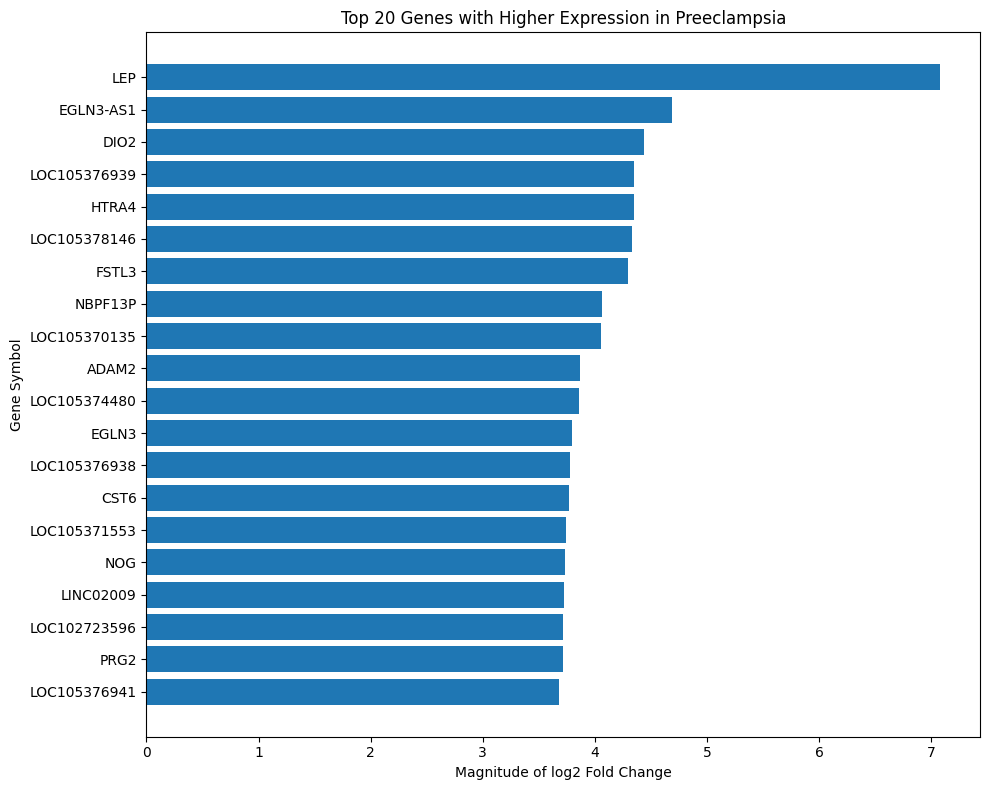

In [24]:
import matplotlib.pyplot as plt

plot_data = top20_pe.sort_values(
    "log2FoldChange",
    ascending=False
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["Symbol"],
    -plot_data["log2FoldChange"]
)

plt.xlabel("Magnitude of log2 Fold Change")
plt.ylabel("Gene Symbol")
plt.title("Top 20 Genes with Higher Expression in Preeclampsia")

plt.tight_layout()
plt.show()

In [25]:
summary_stats = {
    "Total genes analyzed": len(clean_df),
    "Significant DEGs": len(filtered_df),
    "Higher in Normal": len(up_in_normal),
    "Higher in Preeclampsia": len(up_in_pe),
    "Mean log2FC of DEGs": filtered_df["log2FoldChange"].mean(),
    "Median log2FC of DEGs": filtered_df["log2FoldChange"].median()
}

for key, value in summary_stats.items():
    print(f"{key}: {value}")

Total genes analyzed: 18765
Significant DEGs: 854
Higher in Normal: 208
Higher in Preeclampsia: 646
Mean log2FC of DEGs: -1.1512125262295083
Median log2FC of DEGs: -1.4954407


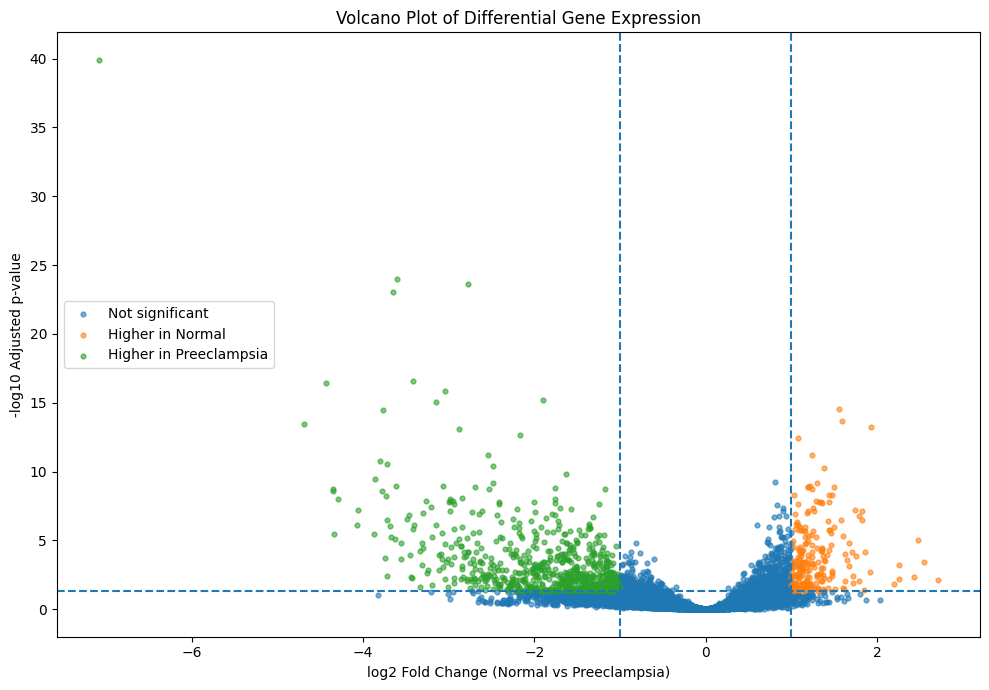

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Make a copy for plotting
volcano_df = clean_df.copy()

# Calculate -log10 adjusted p-value
volcano_df["neg_log10_padj"] = -np.log10(volcano_df["padj"])

# Default category
volcano_df["Category"] = "Not significant"

# Higher in Normal
volcano_df.loc[
    (volcano_df["padj"] < 0.05) &
    (volcano_df["log2FoldChange"] >= 1),
    "Category"
] = "Higher in Normal"

# Higher in Preeclampsia
volcano_df.loc[
    (volcano_df["padj"] < 0.05) &
    (volcano_df["log2FoldChange"] <= -1),
    "Category"
] = "Higher in Preeclampsia"

# Create plot
plt.figure(figsize=(10, 7))

for category in [
    "Not significant",
    "Higher in Normal",
    "Higher in Preeclampsia"
]:
    subset = volcano_df[
        volcano_df["Category"] == category
    ]

    plt.scatter(
        subset["log2FoldChange"],
        subset["neg_log10_padj"],
        s=12,
        alpha=0.6,
        label=category
    )

# Threshold lines
plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change (Normal vs Preeclampsia)")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Volcano Plot of Differential Gene Expression")
plt.legend()

plt.tight_layout()
plt.show()

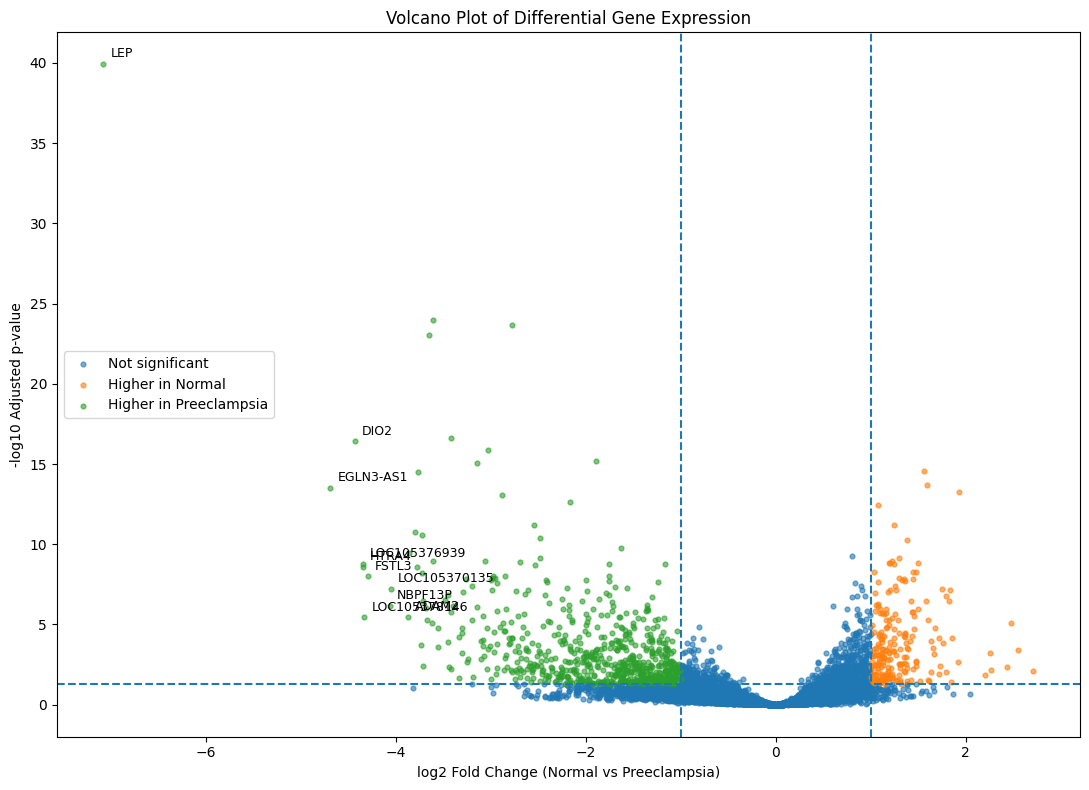

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Select top 10 strongest DEGs by absolute log2FoldChange
top10_labels = filtered_df.copy()

top10_labels["abs_log2FC"] = (
    top10_labels["log2FoldChange"].abs()
)

top10_labels = top10_labels.sort_values(
    "abs_log2FC",
    ascending=False
).head(10)


# Create volcano plot
plt.figure(figsize=(11, 8))

for category in [
    "Not significant",
    "Higher in Normal",
    "Higher in Preeclampsia"
]:
    subset = volcano_df[
        volcano_df["Category"] == category
    ]

    plt.scatter(
        subset["log2FoldChange"],
        subset["neg_log10_padj"],
        s=12,
        alpha=0.6,
        label=category
    )


# Add threshold lines
plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(
    y=-np.log10(0.05),
    linestyle="--"
)


# Add gene labels
for _, row in top10_labels.iterrows():

    y_value = -np.log10(row["padj"])

    plt.annotate(
        row["Symbol"],
        (row["log2FoldChange"], y_value),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )


plt.xlabel(
    "log2 Fold Change (Normal vs Preeclampsia)"
)

plt.ylabel(
    "-log10 Adjusted p-value"
)

plt.title(
    "Volcano Plot of Differential Gene Expression"
)

plt.legend()

plt.tight_layout()
plt.show()

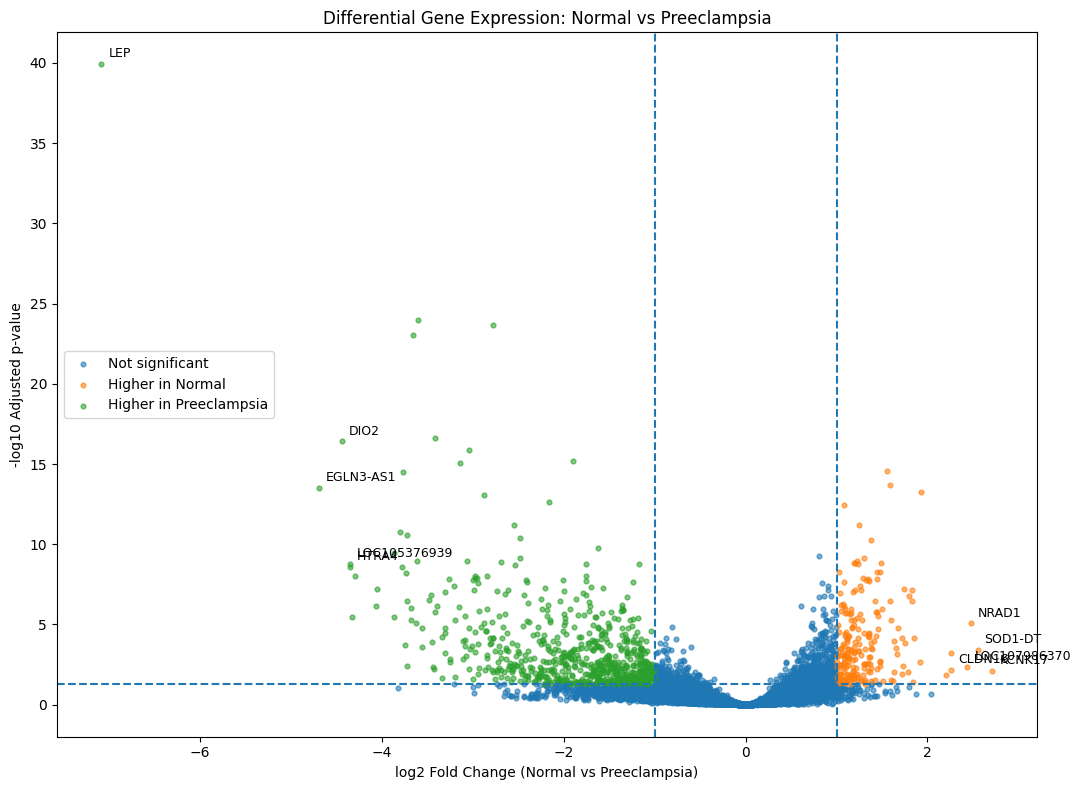

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Select 5 strongest genes higher in Normal
top5_normal = up_in_normal.sort_values(
    "log2FoldChange",
    ascending=False
).head(5)

# Select 5 strongest genes higher in Preeclampsia
top5_pe = up_in_pe.sort_values(
    "log2FoldChange",
    ascending=True
).head(5)

# Combine both groups
label_genes = pd.concat([
    top5_normal,
    top5_pe
])

# Create volcano plot
plt.figure(figsize=(11, 8))

for category in [
    "Not significant",
    "Higher in Normal",
    "Higher in Preeclampsia"
]:
    subset = volcano_df[
        volcano_df["Category"] == category
    ]

    plt.scatter(
        subset["log2FoldChange"],
        subset["neg_log10_padj"],
        s=12,
        alpha=0.6,
        label=category
    )

# Threshold lines
plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")

plt.axhline(
    y=-np.log10(0.05),
    linestyle="--"
)

# Add balanced gene labels
for _, row in label_genes.iterrows():

    y_value = -np.log10(row["padj"])

    plt.annotate(
        row["Symbol"],
        (row["log2FoldChange"], y_value),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel(
    "log2 Fold Change (Normal vs Preeclampsia)"
)

plt.ylabel(
    "-log10 Adjusted p-value"
)

plt.title(
    "Differential Gene Expression: Normal vs Preeclampsia"
)

plt.legend()

plt.tight_layout()
plt.show()

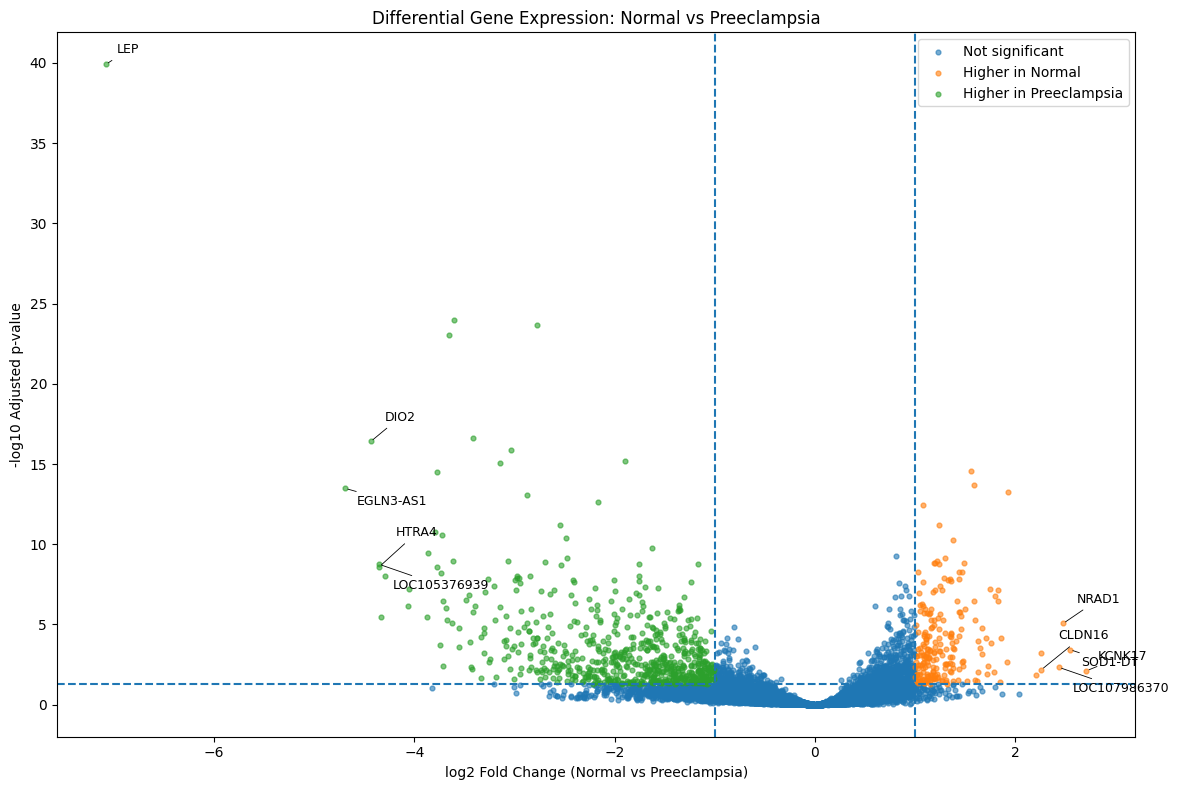

In [29]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for category in [
    "Not significant",
    "Higher in Normal",
    "Higher in Preeclampsia"
]:
    subset = volcano_df[
        volcano_df["Category"] == category
    ]

    plt.scatter(
        subset["log2FoldChange"],
        subset["neg_log10_padj"],
        s=12,
        alpha=0.6,
        label=category
    )

# Threshold lines
plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(
    y=-np.log10(0.05),
    linestyle="--"
)

# Different label positions to reduce overlap
offsets = [
    (8, 8),
    (8, -12),
    (10, 15),
    (10, -18),
    (12, 22),
    (8, 8),
    (8, -12),
    (10, 15),
    (10, -18),
    (12, 22)
]

for (_, row), offset in zip(
    label_genes.iterrows(),
    offsets
):
    y_value = -np.log10(row["padj"])

    plt.annotate(
        row["Symbol"],
        (row["log2FoldChange"], y_value),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.6
        )
    )

plt.xlabel(
    "log2 Fold Change (Normal vs Preeclampsia)"
)
plt.ylabel(
    "-log10 Adjusted p-value"
)
plt.title(
    "Differential Gene Expression: Normal vs Preeclampsia"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "volcano_plot_labeled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Save filtered DEG tables
filtered_df.to_csv("filtered_DEGs_padj0.05_log2FC1.csv", index=False)
up_in_pe.to_csv("genes_higher_in_preeclampsia.csv", index=False)
up_in_normal.to_csv("genes_higher_in_normal.csv", index=False)

# Save summary statistics
summary_df = pd.DataFrame(
    list(summary_stats.items()),
    columns=["Metric", "Value"]
)

summary_df.to_csv("summary_statistics.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')